# 05 - Results: collation across all schemes - CIC-IDS-2017

In [1]:
DATASET = "cic2017"
FT_ROOT = None

In [2]:
import sys
from pathlib import Path

def _find_nb_common():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for c in (cand, cand / "notebooks"):
            if (c / "nb_common.py").exists():
                return c
    raise FileNotFoundError("nb_common.py not found relative to " + str(Path.cwd()))
sys.path.insert(0, str(_find_nb_common()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nb_common as nbc
from ids.evaluation.cross_val import METRIC_NAMES

P = nbc.ft_paths(DATASET, FT_ROOT)
log = nbc.setup_logging(P.logs / "05_results.log", "nb05")

rows = []
for mp in sorted(P.runs.glob("*/*/metrics.json")):
    d = nbc.load_json(mp)
    for split in ("test", "validation"):
        if split in d:
            m = {k: v for k, v in d[split].items() if k != "name"}
            rows.append({"scheme": d["scheme"], "model": d["model"], "split": split,
                         "n_train": d["n_train"], "fit_seconds": d["fit_seconds"], **m})
summary = pd.DataFrame(rows)
summary.to_csv(P.results / "summary_all_schemes.csv", index=False)
log.info("collected %d (scheme, model, split) results", len(summary))
summary.head(10)

2026-07-06 10:39:15,431 INFO nb05: collected 25 (scheme, model, split) results


,scheme,model,split,n_train,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,detection_time_ms,n_test
0,70_20_10,decision_tree,test,1764558,13.740,0.995490,0.742993,0.915183,0.794771,0.997743,0.000280,252080
1,70_20_10,decision_tree,validation,1764558,13.740,0.995363,0.719509,0.923278,0.783346,0.997775,0.000230,504160
2,70_20_10,knn,test,1764558,2.424,0.972771,0.591667,0.951907,0.659421,0.992867,0.461288,252080
3,70_20_10,knn,validation,1764558,2.424,0.972217,0.615717,0.892280,0.669982,0.992731,0.466985,504160
4,70_20_10,naive_bayes,test,1764558,2.304,0.339368,0.314955,0.651737,0.294364,0.949554,0.001167,252080
5,70_20_10,naive_bayes,validation,1764558,2.304,0.339983,0.380750,0.686474,0.359973,0.949178,0.000672,504160
6,70_20_10,random_forest,test,1764558,31.298,0.996291,0.767127,0.847567,0.786955,0.999941,0.003356,252080
7,70_20_10,random_forest,validation,1764558,31.298,0.996059,0.803600,0.898863,0.819516,0.999938,0.003350,504160
8,70_20_10,svm,test,1764558,11.250,0.695668,0.285564,0.756863,0.315158,0.971994,0.000754,252080
9,70_20_10,svm,validation,1764558,11.250,0.695162,0.286544,0.789874,0.317900,0.971627,0.001420,504160


## 1. Test-set comparison: model x scheme, one table per metric

In [3]:
test = summary[summary["split"] == "test"]
pivots = {}
for metric in METRIC_NAMES + ["detection_time_ms", "fit_seconds"]:
    pv = test.pivot_table(index="model", columns="scheme", values=metric).round(4)
    pv.to_csv(P.results / f"pivot_{metric}.csv")
    pivots[metric] = pv
log.info("saved %d pivot tables to %s", len(pivots), P.results)
pivots["f1_macro"]

2026-07-06 10:39:15,465 INFO nb05: saved 7 pivot tables to /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2017/results


scheme,70_20_10,70_30,80_20,90_10
model,,,,
decision_tree,0.7948,0.7583,0.7828,0.7945
knn,0.6594,0.6546,0.6559,0.6160
naive_bayes,0.2944,0.3438,0.3317,0.2897
random_forest,0.7870,0.8019,0.8352,0.7789
svm,0.3152,0.3272,0.3294,0.3198


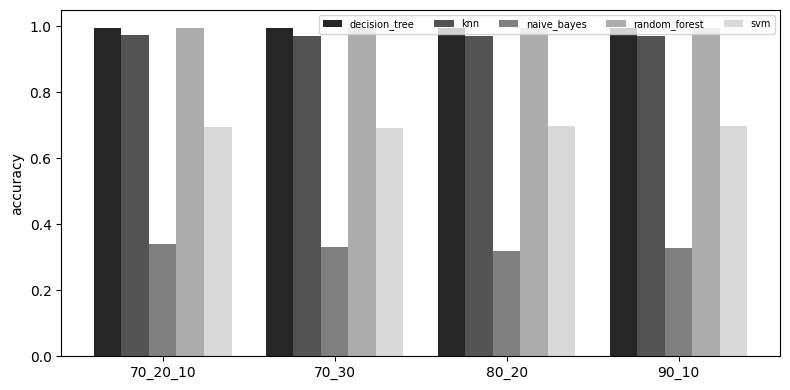

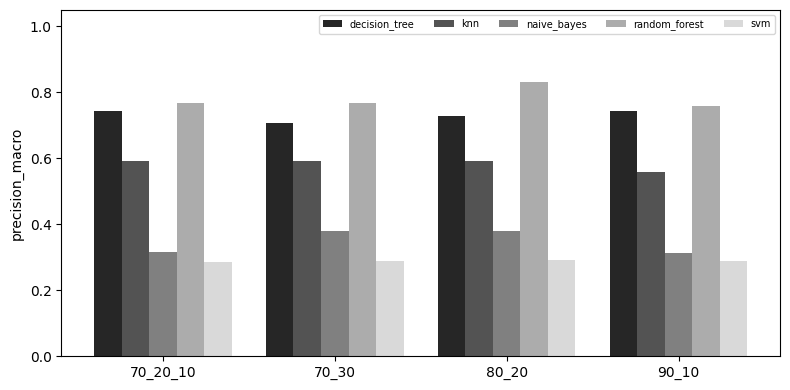

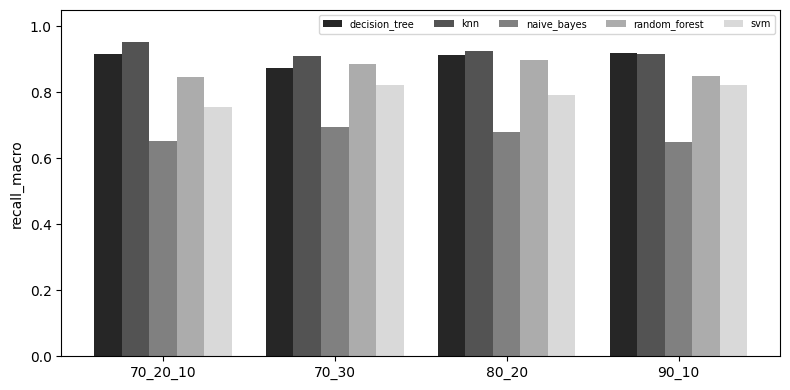

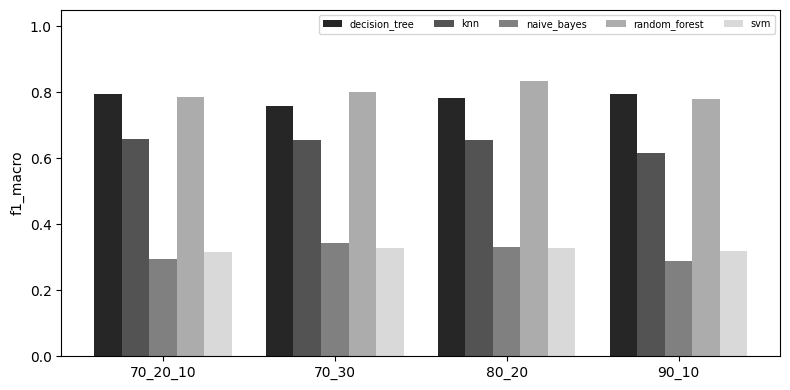

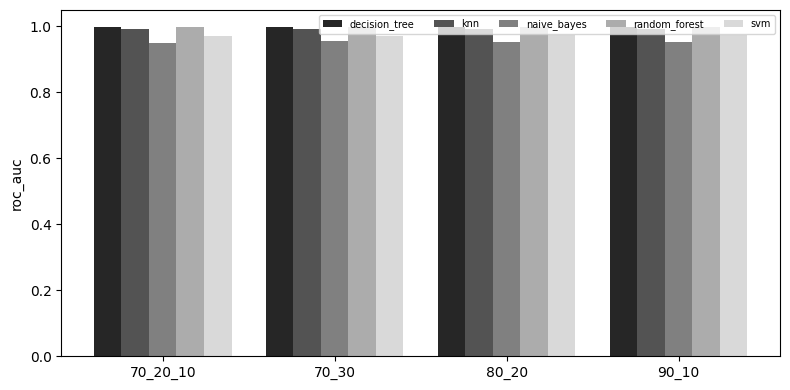

In [4]:
for metric in METRIC_NAMES:
    pv = pivots[metric]
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(pv.columns))
    width = 0.8 / len(pv.index)
    for i, model in enumerate(pv.index):
        ax.bar(x + i * width, pv.loc[model], width,
               label=model, color=str(0.15 + 0.7 * i / max(1, len(pv.index) - 1)))
    ax.set_xticks(x + 0.4 - width / 2)
    ax.set_xticklabels(pv.columns)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7, ncol=len(pv.index))
    fig.tight_layout()
    fig.savefig(P.results / "plots" / f"{metric}_by_scheme.png", dpi=150)
    plt.show()

## 2. Cross-validation (cv5): mean ± std per model

In [5]:
cv_summary_path = P.runs / "cv5" / "cv_summary.csv"
if cv_summary_path.exists():
    cv_summary = pd.read_csv(cv_summary_path)
    cv_summary.to_csv(P.results / "cv5_summary.csv", index=False)
    display(cv_summary.round(4))
else:
    log.warning("no cv5 results found at %s", cv_summary_path)

,model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_mean,roc_auc_std
0,decision_tree,0.9945,0.0003,0.7162,0.0080,0.9154,0.0170,0.7701,0.0069,0.9979,0.0001
1,knn,0.9713,0.0004,0.5883,0.0165,0.8999,0.0142,0.6495,0.0138,0.9925,0.0002
2,naive_bayes,0.3372,0.0062,0.3570,0.0329,0.6906,0.0296,0.3293,0.0237,0.9519,0.0019
3,random_forest,0.9956,0.0001,0.8094,0.0127,0.9056,0.0108,0.8252,0.0066,0.9999,0.0000
4,svm,0.6860,0.0047,0.2859,0.0042,0.7856,0.0188,0.3174,0.0076,0.9720,0.0010


## 3. Validation vs test on the 70/20/10 scheme

In [6]:
vt = summary[summary["scheme"] == "70_20_10"].pivot_table(
    index="model", columns="split",
    values=[m for m in METRIC_NAMES if m in summary.columns]).round(4)
vt.to_csv(P.results / "val_vs_test_70_20_10.csv")
vt

accuracy            f1_macro            precision_macro  \
split             test validation     test validation            test   
model                                                                   
decision_tree   0.9955     0.9954   0.7948     0.7833          0.7430   
knn             0.9728     0.9722   0.6594     0.6700          0.5917   
naive_bayes     0.3394     0.3400   0.2944     0.3600          0.3150   
random_forest   0.9963     0.9961   0.7870     0.8195          0.7671   
svm             0.6957     0.6952   0.3152     0.3179          0.2856   

                         recall_macro            roc_auc             
split         validation         test validation    test validation  
model                                                                
decision_tree     0.7195       0.9152     0.9233  0.9977     0.9978  
knn               0.6157       0.9519     0.8923  0.9929     0.9927  
naive_bayes       0.3807       0.6517     0.6865  0.9496     0.9492  
random_forest     0.8036       0.8476     0.8989  0.9999     0.9999  
svm               0.2865       0.7569     0.7899  0.9720     0.9716

## 4. Artifact inventory

In [7]:
inventory = sorted(str(p.relative_to(P.root)) for p in P.root.rglob("*") if p.is_file())
nbc.save_json(inventory, P.results / "artifact_inventory.json")
log.info("study produced %d artifact files under %s", len(inventory), P.root)
print(f"{len(inventory)} files; key results:")
for f in inventory:
    if f.startswith("results/") and f.endswith(".csv"):
        print(" ", f)

2026-07-06 10:39:15,943 INFO nb05: study produced 190 artifact files under /Users/MAC/Projects/IDS/backend/artifacts/ft40/cic2017
190 files; key results:
  results/cv5_summary.csv
  results/pivot_accuracy.csv
  results/pivot_detection_time_ms.csv
  results/pivot_f1_macro.csv
  results/pivot_fit_seconds.csv
  results/pivot_precision_macro.csv
  results/pivot_recall_macro.csv
  results/pivot_roc_auc.csv
  results/summary_all_schemes.csv
  results/val_vs_test_70_20_10.csv
